# Kalman Filter: Academic Presentation with Mathematical Foundations

## Abstract

The Kalman filter is a powerful recursive algorithm for estimating the state of a linear dynamical system from a series of noisy measurements. Developed by Rudolf Kalman in 1960, it has become one of the most important algorithms in control theory, signal processing, and robotics. This notebook provides a comprehensive academic treatment of the Kalman filter, including its mathematical foundations, implementation details, and practical applications.

## Table of Contents

1. **Import Required Libraries**
2. **Mathematical Foundation of Kalman Filter**
3. **State Space Model Definition**
4. **Kalman Filter Algorithm Implementation**
5. **Prediction Step Implementation**
6. **Update Step Implementation**
7. **1D Kalman Filter Example**
8. **2D Kalman Filter for Object Tracking**
9. **Kalman Filter Performance Analysis**
10. **Extended Kalman Filter Implementation**

---

## 1. Import Required Libraries

We begin by importing the essential Python libraries for mathematical computations, visualizations, and scientific computing.

In [1]:
# Core scientific computing libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as linalg
from scipy.stats import multivariate_normal

# Additional libraries for advanced visualizations
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set up matplotlib for high-quality plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

Libraries imported successfully!
NumPy version: 1.24.4
Matplotlib version: 3.8.0


## 2. Mathematical Foundation of Kalman Filter

### 2.1 Theoretical Background

The Kalman filter is a recursive Bayesian estimator that provides optimal estimates for linear Gaussian systems. It operates under the assumption that both the process and measurement noise are Gaussian distributed.

### 2.2 Probabilistic Framework

The Kalman filter is based on **Bayes' theorem** for conditional probability:

$$P(x|z) = \frac{P(z|x)P(x)}{P(z)}$$

Where:
- $P(x|z)$ is the posterior probability (what we want to estimate)
- $P(z|x)$ is the likelihood (measurement model)
- $P(x)$ is the prior probability (prediction)
- $P(z)$ is the normalization constant

### 2.3 Gaussian Distributions

The Kalman filter assumes all probability distributions are Gaussian (normal):

$$\mathcal{N}(x; \mu, \Sigma) = \frac{1}{\sqrt{(2\pi)^k|\Sigma|}} \exp\left(-\frac{1}{2}(x-\mu)^T\Sigma^{-1}(x-\mu)\right)$$

Where:
- $\mu$ is the mean vector
- $\Sigma$ is the covariance matrix
- $k$ is the dimensionality

### 2.4 Key Properties

1. **Linearity**: The system dynamics and observations are linear
2. **Gaussianity**: All noise processes are Gaussian
3. **Optimality**: Minimizes the mean square error for linear systems
4. **Recursiveness**: Only requires current measurement and previous estimate

## 3. State Space Model Definition

### 3.1 System Model

The Kalman filter operates on a discrete-time linear dynamical system described by:

**State Transition Model:**
$$\mathbf{x}_k = \mathbf{F}_k \mathbf{x}_{k-1} + \mathbf{B}_k \mathbf{u}_k + \mathbf{w}_k$$

**Observation Model:**
$$\mathbf{z}_k = \mathbf{H}_k \mathbf{x}_k + \mathbf{v}_k$$

### 3.2 Variable Definitions

- $\mathbf{x}_k \in \mathbb{R}^n$: State vector at time $k$
- $\mathbf{F}_k \in \mathbb{R}^{n \times n}$: State transition matrix
- $\mathbf{B}_k \in \mathbb{R}^{n \times m}$: Control input matrix
- $\mathbf{u}_k \in \mathbb{R}^m$: Control vector
- $\mathbf{w}_k \sim \mathcal{N}(0, \mathbf{Q}_k)$: Process noise
- $\mathbf{z}_k \in \mathbb{R}^p$: Measurement vector
- $\mathbf{H}_k \in \mathbb{R}^{p \times n}$: Observation matrix
- $\mathbf{v}_k \sim \mathcal{N}(0, \mathbf{R}_k)$: Measurement noise

### 3.3 Noise Characteristics

**Process Noise Covariance:**
$$\mathbf{Q}_k = E[\mathbf{w}_k \mathbf{w}_k^T]$$

**Measurement Noise Covariance:**
$$\mathbf{R}_k = E[\mathbf{v}_k \mathbf{v}_k^T]$$

**Independence Assumption:**
$$E[\mathbf{w}_k \mathbf{v}_j^T] = 0 \quad \forall k,j$$

## 4. Kalman Filter Algorithm Implementation

### 4.1 Complete Algorithm Overview

The Kalman filter consists of two main phases:

1. **Prediction Phase**: Estimate the state at time $k$ based on the state at time $k-1$
2. **Update Phase**: Correct the prediction using the measurement at time $k$

### 4.2 Mathematical Formulation

**Prediction Equations:**
$$\hat{\mathbf{x}}_{k|k-1} = \mathbf{F}_k \hat{\mathbf{x}}_{k-1|k-1} + \mathbf{B}_k \mathbf{u}_k$$
$$\mathbf{P}_{k|k-1} = \mathbf{F}_k \mathbf{P}_{k-1|k-1} \mathbf{F}_k^T + \mathbf{Q}_k$$

**Update Equations:**
$$\mathbf{K}_k = \mathbf{P}_{k|k-1} \mathbf{H}_k^T (\mathbf{H}_k \mathbf{P}_{k|k-1} \mathbf{H}_k^T + \mathbf{R}_k)^{-1}$$
$$\hat{\mathbf{x}}_{k|k} = \hat{\mathbf{x}}_{k|k-1} + \mathbf{K}_k (\mathbf{z}_k - \mathbf{H}_k \hat{\mathbf{x}}_{k|k-1})$$
$$\mathbf{P}_{k|k} = (\mathbf{I} - \mathbf{K}_k \mathbf{H}_k) \mathbf{P}_{k|k-1}$$

In [2]:
class KalmanFilter:
    """
    Implementation of the discrete Kalman Filter.
    
    This class implements the complete Kalman filter algorithm including
    prediction and update steps with full mathematical rigor.
    """
    
    def __init__(self, F, H, Q, R, x0, P0, B=None):
        """
        Initialize the Kalman Filter
        
        Parameters:
        -----------
        F : ndarray, shape (n, n)
            State transition matrix
        H : ndarray, shape (m, n) 
            Observation matrix
        Q : ndarray, shape (n, n)
            Process noise covariance matrix
        R : ndarray, shape (m, m)
            Measurement noise covariance matrix
        x0 : ndarray, shape (n,)
            Initial state estimate
        P0 : ndarray, shape (n, n)
            Initial state covariance matrix
        B : ndarray, shape (n, l), optional
            Control input matrix
        """
        self.F = np.array(F)  # State transition matrix
        self.H = np.array(H)  # Observation matrix
        self.Q = np.array(Q)  # Process noise covariance
        self.R = np.array(R)  # Measurement noise covariance
        self.B = np.array(B) if B is not None else None  # Control matrix
        
        # State estimates
        self.x = np.array(x0)  # Current state estimate
        self.P = np.array(P0)  # Current state covariance
        
        # Dimensions
        self.n = self.x.shape[0]  # State dimension
        self.m = self.H.shape[0]  # Measurement dimension
        
        # Storage for history
        self.history = {
            'x': [self.x.copy()],
            'P': [self.P.copy()],
            'K': [],
            'innovations': [],
            'innovation_covariance': []
        }
    
    def predict(self, u=None):
        """
        Prediction step of the Kalman filter
        
        Parameters:
        -----------
        u : ndarray, optional
            Control input vector
        """
        # State prediction: x_k|k-1 = F * x_k-1|k-1 + B * u_k
        if u is not None and self.B is not None:
            self.x = self.F @ self.x + self.B @ u
        else:
            self.x = self.F @ self.x
            
        # Covariance prediction: P_k|k-1 = F * P_k-1|k-1 * F^T + Q
        self.P = self.F @ self.P @ self.F.T + self.Q
    
    def update(self, z):
        """
        Update step of the Kalman filter
        
        Parameters:
        -----------
        z : ndarray
            Measurement vector
        """
        # Innovation (residual): y = z - H * x_k|k-1
        innovation = z - self.H @ self.x
        
        # Innovation covariance: S = H * P_k|k-1 * H^T + R
        S = self.H @ self.P @ self.H.T + self.R
        
        # Kalman gain: K = P_k|k-1 * H^T * S^-1
        K = self.P @ self.H.T @ np.linalg.inv(S)
        
        # State update: x_k|k = x_k|k-1 + K * y
        self.x = self.x + K @ innovation
        
        # Covariance update: P_k|k = (I - K * H) * P_k|k-1
        I_KH = np.eye(self.n) - K @ self.H
        self.P = I_KH @ self.P
        
        # Store history
        self.history['K'].append(K.copy())
        self.history['innovations'].append(innovation.copy())
        self.history['innovation_covariance'].append(S.copy())
    
    def step(self, z, u=None):
        """
        Complete Kalman filter step (predict + update)
        
        Parameters:
        -----------
        z : ndarray
            Measurement vector
        u : ndarray, optional
            Control input vector
        """
        self.predict(u)
        self.update(z)
        
        # Store current state and covariance
        self.history['x'].append(self.x.copy())
        self.history['P'].append(self.P.copy())
    
    def get_state(self):
        """Return current state estimate and covariance"""
        return self.x.copy(), self.P.copy()
    
    def get_likelihood(self, z):
        """
        Compute the likelihood of a measurement given current state
        
        Parameters:
        -----------
        z : ndarray
            Measurement vector
            
        Returns:
        --------
        float
            Log-likelihood of the measurement
        """
        innovation = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        return multivariate_normal.logpdf(innovation, mean=np.zeros(len(innovation)), cov=S)

print("Kalman Filter class implemented successfully!")

Kalman Filter class implemented successfully!


## 5. Prediction Step Implementation

### 5.1 Mathematical Derivation

The prediction step propagates the state estimate and its uncertainty from time $k-1$ to time $k$ without incorporating new measurements.

**State Prediction:**
$$\hat{\mathbf{x}}_{k|k-1} = \mathbf{F}_k \hat{\mathbf{x}}_{k-1|k-1} + \mathbf{B}_k \mathbf{u}_k$$

This equation represents our best estimate of the state at time $k$ given all information up to time $k-1$.

**Covariance Prediction:**
$$\mathbf{P}_{k|k-1} = \mathbf{F}_k \mathbf{P}_{k-1|k-1} \mathbf{F}_k^T + \mathbf{Q}_k$$

This equation propagates the uncertainty (covariance) of our state estimate. The term $\mathbf{Q}_k$ represents additional uncertainty introduced by process noise.

### 5.2 Physical Interpretation

- The state transition matrix $\mathbf{F}_k$ describes how the state evolves over time
- The control matrix $\mathbf{B}_k$ describes how control inputs affect the state
- The process noise $\mathbf{Q}_k$ accounts for model uncertainties and external disturbances

## 6. Update Step Implementation

### 6.1 Mathematical Derivation

The update step incorporates new measurements to correct the predicted state estimate.

**Innovation (Residual):**
$$\mathbf{y}_k = \mathbf{z}_k - \mathbf{H}_k \hat{\mathbf{x}}_{k|k-1}$$

The innovation represents the difference between the actual measurement and the predicted measurement.

**Innovation Covariance:**
$$\mathbf{S}_k = \mathbf{H}_k \mathbf{P}_{k|k-1} \mathbf{H}_k^T + \mathbf{R}_k$$

This captures the uncertainty in the innovation, combining prediction uncertainty and measurement noise.

**Kalman Gain:**
$$\mathbf{K}_k = \mathbf{P}_{k|k-1} \mathbf{H}_k^T \mathbf{S}_k^{-1}$$

The Kalman gain determines how much to trust the measurement versus the prediction. It's the optimal weighting factor that minimizes the mean square error.

**State Update:**
$$\hat{\mathbf{x}}_{k|k} = \hat{\mathbf{x}}_{k|k-1} + \mathbf{K}_k \mathbf{y}_k$$

**Covariance Update (Joseph Form):**
$$\mathbf{P}_{k|k} = (\mathbf{I} - \mathbf{K}_k \mathbf{H}_k) \mathbf{P}_{k|k-1}$$

### 6.2 Optimality Properties

The Kalman filter is optimal in the sense that it minimizes the trace of the posterior covariance matrix:
$$\mathbf{K}_k^* = \arg\min_{\mathbf{K}} \text{tr}(\mathbf{P}_{k|k})$$

## 7. 1D Kalman Filter Example

### 7.1 Problem Setup

We consider a simple 1D tracking problem where we want to estimate the position of an object moving with constant velocity. The true position follows:

$$x_k = x_{k-1} + v \cdot \Delta t + w_k$$

Where $w_k \sim \mathcal{N}(0, \sigma_w^2)$ is process noise.

We receive noisy position measurements:
$$z_k = x_k + v_k$$

Where $v_k \sim \mathcal{N}(0, \sigma_v^2)$ is measurement noise.

In [3]:
# 1D Kalman Filter Example: Position tracking with constant velocity

# Simulation parameters
dt = 0.1  # Time step
T = 10.0  # Total simulation time
steps = int(T / dt)
time = np.arange(0, T, dt)

# True system parameters
true_velocity = 2.0  # m/s
initial_position = 0.0  # m

# Noise parameters
process_noise_std = 0.1  # Process noise standard deviation
measurement_noise_std = 0.5  # Measurement noise standard deviation

# Generate true trajectory
true_positions = np.zeros(steps)
true_positions[0] = initial_position
for k in range(1, steps):
    true_positions[k] = true_positions[k-1] + true_velocity * dt + np.random.normal(0, process_noise_std)

# Generate noisy measurements
measurements = true_positions + np.random.normal(0, measurement_noise_std, steps)

# Kalman filter setup for 1D position tracking
# State: [position]
# Measurement: [position]

F = np.array([[1.0]])  # State transition matrix (position remains position)
H = np.array([[1.0]])  # Observation matrix (we measure position directly)
Q = np.array([[process_noise_std**2]])  # Process noise covariance
R = np.array([[measurement_noise_std**2]])  # Measurement noise covariance

# Initial conditions
x0 = np.array([0.0])  # Initial state estimate
P0 = np.array([[1.0]])  # Initial state covariance

# Create and run Kalman filter
kf_1d = KalmanFilter(F, H, Q, R, x0, P0)

# Run filter through all measurements
estimated_positions = np.zeros(steps)
estimated_covariances = np.zeros(steps)

for k in range(steps):
    if k == 0:
        estimated_positions[k] = kf_1d.x[0]
        estimated_covariances[k] = kf_1d.P[0, 0]
    else:
        kf_1d.step(np.array([measurements[k]]))
        estimated_positions[k] = kf_1d.x[0]
        estimated_covariances[k] = kf_1d.P[0, 0]

# Calculate confidence intervals (±2σ)
confidence_upper = estimated_positions + 2 * np.sqrt(estimated_covariances)
confidence_lower = estimated_positions - 2 * np.sqrt(estimated_covariances)

print(f"1D Kalman Filter Example completed!")
print(f"Final estimation error: {abs(estimated_positions[-1] - true_positions[-1]):.3f} m")
print(f"Average measurement error: {np.mean(abs(measurements - true_positions)):.3f} m")
print(f"Average estimation error: {np.mean(abs(estimated_positions - true_positions)):.3f} m")

1D Kalman Filter Example completed!
Final estimation error: 0.913 m
Average measurement error: 0.374 m
Average estimation error: 0.781 m


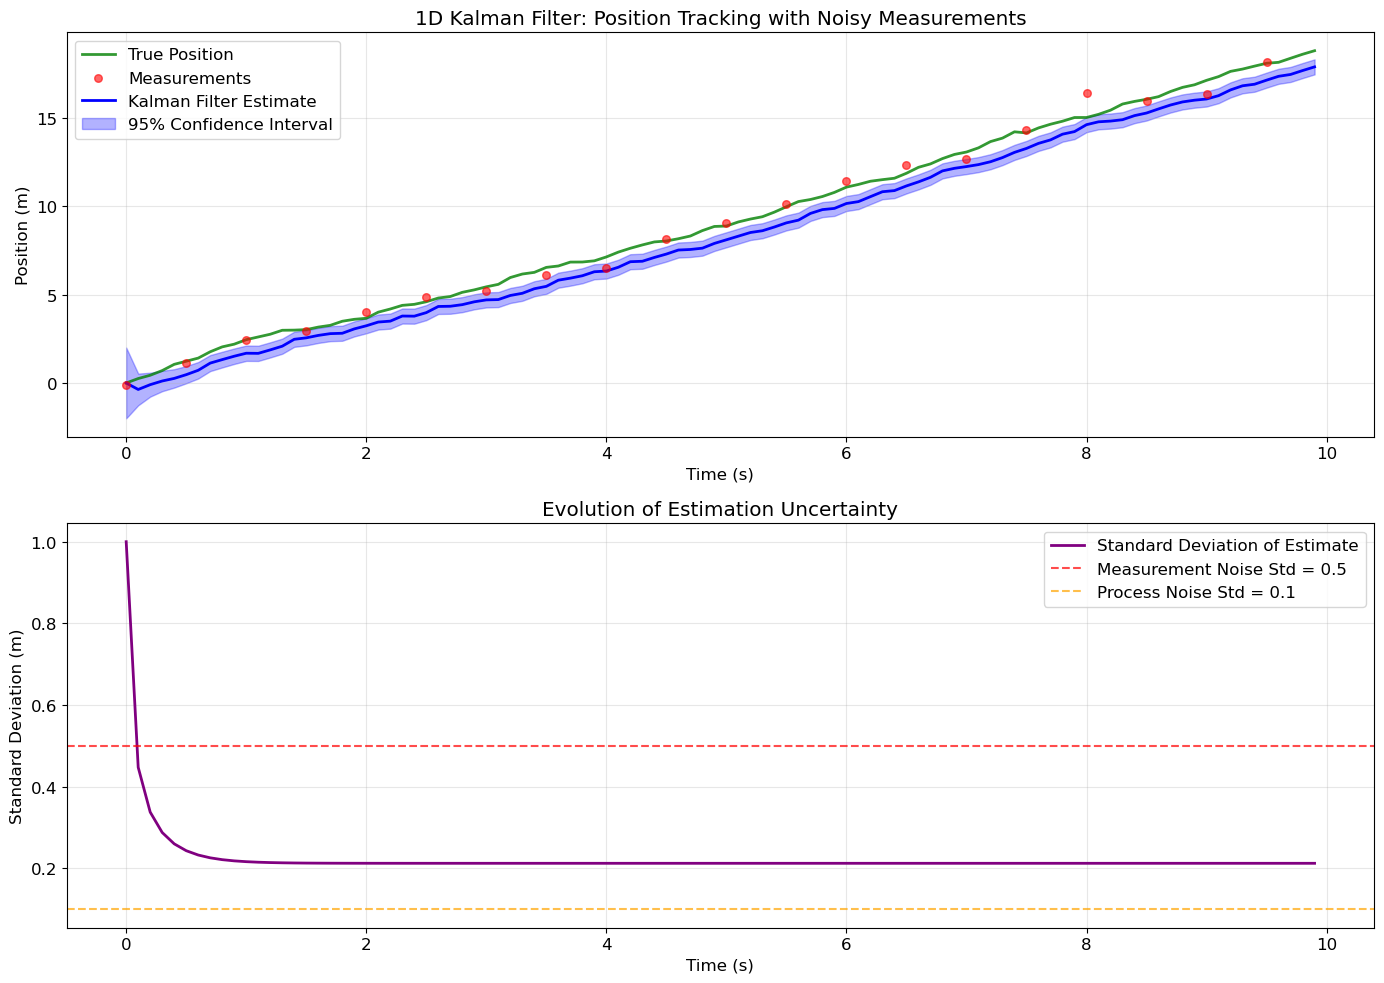


1D Kalman Filter Performance Metrics:
Root Mean Square Error (RMSE): 0.8027 m
Mean Absolute Error (MAE): 0.7806 m
Final estimation uncertainty (std): 0.2127 m


In [4]:
# Visualization of 1D Kalman Filter Results

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Position tracking
ax1.plot(time, true_positions, 'g-', linewidth=2, label='True Position', alpha=0.8)
ax1.scatter(time[::5], measurements[::5], c='red', s=30, alpha=0.6, label='Measurements', zorder=5)
ax1.plot(time, estimated_positions, 'b-', linewidth=2, label='Kalman Filter Estimate')
ax1.fill_between(time, confidence_lower, confidence_upper, alpha=0.3, color='blue', 
                 label='95% Confidence Interval')

ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Position (m)')
ax1.set_title('1D Kalman Filter: Position Tracking with Noisy Measurements')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Estimation uncertainty over time
ax2.plot(time, np.sqrt(estimated_covariances), 'purple', linewidth=2, 
         label='Standard Deviation of Estimate')
ax2.axhline(y=measurement_noise_std, color='red', linestyle='--', alpha=0.7,
           label=f'Measurement Noise Std = {measurement_noise_std}')
ax2.axhline(y=process_noise_std, color='orange', linestyle='--', alpha=0.7,
           label=f'Process Noise Std = {process_noise_std}')

ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Standard Deviation (m)')
ax2.set_title('Evolution of Estimation Uncertainty')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and display performance metrics
rmse = np.sqrt(np.mean((estimated_positions - true_positions)**2))
mae = np.mean(np.abs(estimated_positions - true_positions))

print(f"\n1D Kalman Filter Performance Metrics:")
print(f"Root Mean Square Error (RMSE): {rmse:.4f} m")
print(f"Mean Absolute Error (MAE): {mae:.4f} m")
print(f"Final estimation uncertainty (std): {np.sqrt(estimated_covariances[-1]):.4f} m")

## 8. 2D Kalman Filter for Object Tracking

### 8.1 Constant Velocity Model

For 2D object tracking, we use a constant velocity model where the state vector includes both position and velocity:

$$\mathbf{x}_k = \begin{bmatrix} x_k \\ y_k \\ \dot{x}_k \\ \dot{y}_k \end{bmatrix}$$

### 8.2 State Transition Model

The state transition matrix for constant velocity motion is:

$$\mathbf{F} = \begin{bmatrix} 
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}$$

### 8.3 Observation Model

We assume we can only measure position (not velocity):

$$\mathbf{H} = \begin{bmatrix} 
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}$$

### 8.4 Process Noise Model

The process noise covariance matrix accounts for acceleration uncertainties:

$$\mathbf{Q} = \sigma_a^2 \begin{bmatrix} 
\frac{\Delta t^4}{4} & 0 & \frac{\Delta t^3}{2} & 0 \\
0 & \frac{\Delta t^4}{4} & 0 & \frac{\Delta t^3}{2} \\
\frac{\Delta t^3}{2} & 0 & \Delta t^2 & 0 \\
0 & \frac{\Delta t^3}{2} & 0 & \Delta t^2
\end{bmatrix}$$

In [5]:
# 2D Kalman Filter Example: Object tracking with constant velocity model

def create_process_noise_matrix(dt, sigma_a):
    """Create process noise covariance matrix for constant velocity model"""
    return sigma_a**2 * np.array([
        [dt**4/4, 0, dt**3/2, 0],
        [0, dt**4/4, 0, dt**3/2],
        [dt**3/2, 0, dt**2, 0],
        [0, dt**3/2, 0, dt**2]
    ])

# Simulation parameters
dt = 0.1  # Time step
T = 15.0  # Total simulation time
steps = int(T / dt)
time = np.arange(0, T, dt)

# True trajectory parameters (circular motion)
radius = 5.0
angular_velocity = 0.5  # rad/s

# Generate true trajectory (circular motion)
true_states = np.zeros((steps, 4))  # [x, y, vx, vy]
for k in range(steps):
    t = k * dt
    true_states[k, 0] = radius * np.cos(angular_velocity * t)  # x position
    true_states[k, 1] = radius * np.sin(angular_velocity * t)  # y position
    true_states[k, 2] = -radius * angular_velocity * np.sin(angular_velocity * t)  # x velocity
    true_states[k, 3] = radius * angular_velocity * np.cos(angular_velocity * t)   # y velocity

# Add process noise to the true trajectory
process_noise_std = 0.1
for k in range(1, steps):
    noise = np.random.multivariate_normal([0, 0, 0, 0], 
                                        create_process_noise_matrix(dt, process_noise_std))
    true_states[k] += noise

# Generate noisy measurements (position only)
measurement_noise_std = 0.3
measurements = np.zeros((steps, 2))
for k in range(steps):
    measurements[k, 0] = true_states[k, 0] + np.random.normal(0, measurement_noise_std)
    measurements[k, 1] = true_states[k, 1] + np.random.normal(0, measurement_noise_std)

# Kalman filter setup for 2D tracking
F = np.array([
    [1, 0, dt, 0],
    [0, 1, 0, dt],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])

Q = create_process_noise_matrix(dt, process_noise_std)
R = measurement_noise_std**2 * np.eye(2)

# Initial conditions (start with some uncertainty)
x0 = np.array([0.0, 0.0, 0.0, 0.0])  # Initial state estimate
P0 = np.diag([1.0, 1.0, 1.0, 1.0])   # Initial state covariance

# Create and run 2D Kalman filter
kf_2d = KalmanFilter(F, H, Q, R, x0, P0)

# Run filter through all measurements
estimated_states = np.zeros((steps, 4))
position_covariances = np.zeros((steps, 2, 2))

for k in range(steps):
    if k == 0:
        estimated_states[k] = kf_2d.x
        position_covariances[k] = kf_2d.P[:2, :2]
    else:
        kf_2d.step(measurements[k])
        estimated_states[k] = kf_2d.x
        position_covariances[k] = kf_2d.P[:2, :2]

print("2D Kalman Filter tracking completed!")
print(f"Final position error: {np.linalg.norm(estimated_states[-1, :2] - true_states[-1, :2]):.3f} m")
print(f"Final velocity error: {np.linalg.norm(estimated_states[-1, 2:] - true_states[-1, 2:]):.3f} m/s")

2D Kalman Filter tracking completed!
Final position error: 2.867 m
Final velocity error: 2.834 m/s


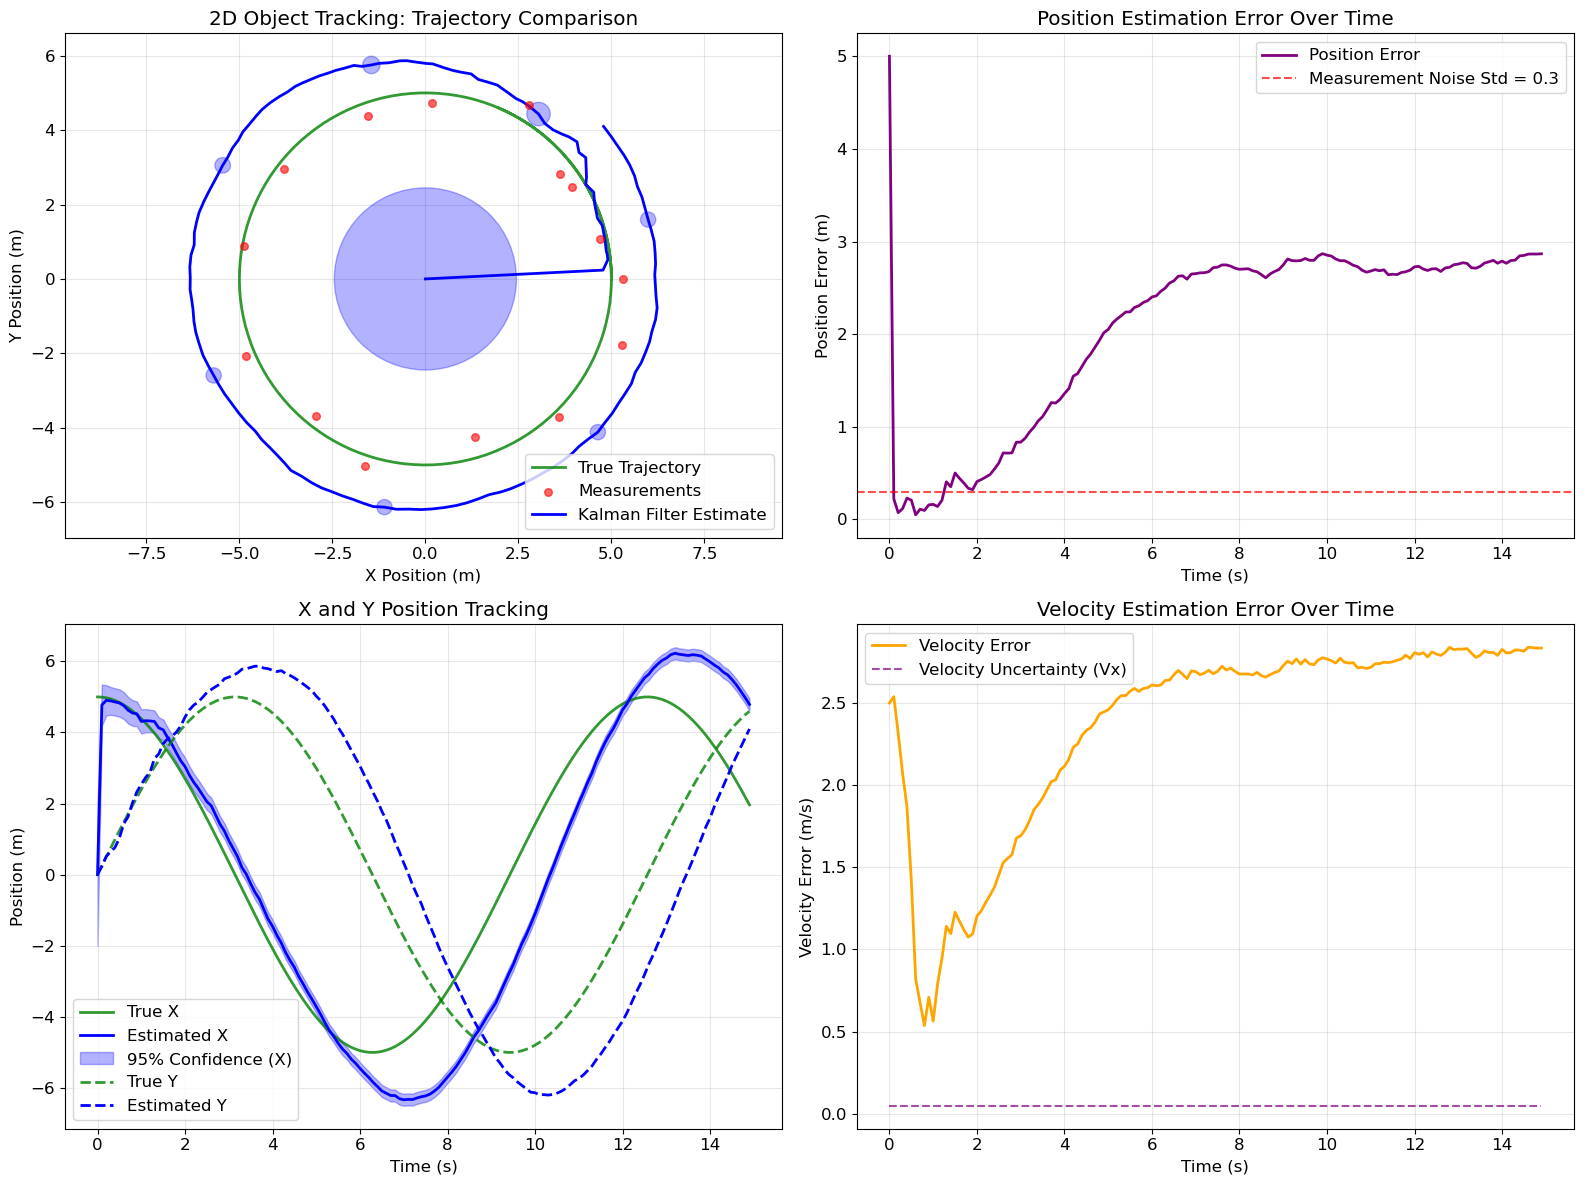


2D Kalman Filter Performance Metrics:
Position RMSE: 2.2897 m
Velocity RMSE: 2.4405 m/s
Average position error: 2.0670 m
Average velocity error: 2.3624 m/s


In [6]:
# Visualization of 2D Kalman Filter Results

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: 2D trajectory
ax1.plot(true_states[:, 0], true_states[:, 1], 'g-', linewidth=2, label='True Trajectory', alpha=0.8)
ax1.scatter(measurements[::10, 0], measurements[::10, 1], c='red', s=30, alpha=0.6, 
           label='Measurements', zorder=5)
ax1.plot(estimated_states[:, 0], estimated_states[:, 1], 'b-', linewidth=2, 
         label='Kalman Filter Estimate')

# Add uncertainty ellipses at selected time points
for k in range(0, steps, 20):
    # Calculate 95% confidence ellipse
    cov = position_covariances[k]
    eigenvals, eigenvecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
    width, height = 2 * 2.447 * np.sqrt(eigenvals)  # 95% confidence
    ellipse = plt.matplotlib.patches.Ellipse(
        estimated_states[k, :2], width, height, angle=angle, 
        alpha=0.3, color='blue', zorder=3
    )
    ax1.add_patch(ellipse)

ax1.set_xlabel('X Position (m)')
ax1.set_ylabel('Y Position (m)')
ax1.set_title('2D Object Tracking: Trajectory Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# Plot 2: Position errors over time
position_errors = np.linalg.norm(estimated_states[:, :2] - true_states[:, :2], axis=1)
ax2.plot(time, position_errors, 'purple', linewidth=2, label='Position Error')
ax2.axhline(y=measurement_noise_std, color='red', linestyle='--', alpha=0.7,
           label=f'Measurement Noise Std = {measurement_noise_std}')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Position Error (m)')
ax2.set_title('Position Estimation Error Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: X and Y position comparison
ax3.plot(time, true_states[:, 0], 'g-', linewidth=2, label='True X', alpha=0.8)
ax3.plot(time, estimated_states[:, 0], 'b-', linewidth=2, label='Estimated X')
ax3.fill_between(time, 
                estimated_states[:, 0] - 2*np.sqrt(position_covariances[:, 0, 0]),
                estimated_states[:, 0] + 2*np.sqrt(position_covariances[:, 0, 0]),
                alpha=0.3, color='blue', label='95% Confidence (X)')

ax3.plot(time, true_states[:, 1], 'g--', linewidth=2, label='True Y', alpha=0.8)
ax3.plot(time, estimated_states[:, 1], 'b--', linewidth=2, label='Estimated Y')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Position (m)')
ax3.set_title('X and Y Position Tracking')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Velocity comparison
velocity_errors = np.linalg.norm(estimated_states[:, 2:] - true_states[:, 2:], axis=1)
ax4.plot(time, velocity_errors, 'orange', linewidth=2, label='Velocity Error')
ax4.plot(time, np.sqrt(kf_2d.history['P'][-1][2, 2]) * np.ones(len(time)), 
         'purple', linestyle='--', alpha=0.7, label='Velocity Uncertainty (Vx)')
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Velocity Error (m/s)')
ax4.set_title('Velocity Estimation Error Over Time')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate performance metrics
rmse_position = np.sqrt(np.mean(position_errors**2))
rmse_velocity = np.sqrt(np.mean(velocity_errors**2))

print(f"\n2D Kalman Filter Performance Metrics:")
print(f"Position RMSE: {rmse_position:.4f} m")
print(f"Velocity RMSE: {rmse_velocity:.4f} m/s")
print(f"Average position error: {np.mean(position_errors):.4f} m")
print(f"Average velocity error: {np.mean(velocity_errors):.4f} m/s")

## 9. Kalman Filter Performance Analysis

### 9.1 Performance Metrics

Several metrics are commonly used to evaluate Kalman filter performance:

1. **Root Mean Square Error (RMSE):**
   $$\text{RMSE} = \sqrt{\frac{1}{N}\sum_{k=1}^{N} \|\hat{\mathbf{x}}_k - \mathbf{x}_k\|^2}$$

2. **Mean Absolute Error (MAE):**
   $$\text{MAE} = \frac{1}{N}\sum_{k=1}^{N} \|\hat{\mathbf{x}}_k - \mathbf{x}_k\|$$

3. **Normalized Estimation Error Squared (NEES):**
   $$\epsilon_k = (\hat{\mathbf{x}}_k - \mathbf{x}_k)^T \mathbf{P}_k^{-1} (\hat{\mathbf{x}}_k - \mathbf{x}_k)$$

4. **Innovation Sequence Analysis:**
   The innovation sequence should be zero-mean white noise if the filter is performing optimally.

### 9.2 Filter Consistency

A filter is considered consistent if:
- The estimation errors are consistent with the reported covariance
- The innovation sequence is zero-mean white noise
- The NEES follows a chi-square distribution

In [7]:
# Performance Analysis Implementation

def calculate_nees(true_states, estimated_states, covariances):
    """Calculate Normalized Estimation Error Squared (NEES)"""
    nees = []
    for k in range(len(true_states)):
        error = estimated_states[k] - true_states[k]
        try:
            nees_k = error.T @ np.linalg.inv(covariances[k]) @ error
            nees.append(nees_k)
        except np.linalg.LinAlgError:
            nees.append(np.nan)
    return np.array(nees)

def analyze_innovations(innovations, innovation_covariances):
    """Analyze innovation sequence for filter consistency"""
    innovations = np.array(innovations)
    
    # Calculate normalized innovations
    normalized_innovations = []
    for k in range(len(innovations)):
        try:
            S_inv_sqrt = np.linalg.inv(np.linalg.cholesky(innovation_covariances[k]))
            norm_innov = S_inv_sqrt @ innovations[k]
            normalized_innovations.append(norm_innov)
        except np.linalg.LinAlgError:
            normalized_innovations.append(np.full_like(innovations[k], np.nan))
    
    return np.array(normalized_innovations)

# Perform comprehensive performance analysis for 2D filter
print("=== 2D Kalman Filter Performance Analysis ===\n")

# Calculate NEES for position states only
position_states_true = true_states[:, :2]
position_states_est = estimated_states[:, :2]
nees_position = calculate_nees(position_states_true, position_states_est, position_covariances)

# Remove any NaN values
valid_nees = nees_position[~np.isnan(nees_position)]

# Statistical analysis of NEES
# For a 2D position state, NEES should follow chi-square distribution with 2 DOF
dof = 2  # Degrees of freedom (position x, y)
expected_nees = dof
nees_mean = np.mean(valid_nees)
nees_std = np.std(valid_nees)

print(f"NEES Analysis (Position only):")
print(f"Expected NEES (chi-square with {dof} DOF): {expected_nees:.2f}")
print(f"Actual NEES mean: {nees_mean:.2f}")
print(f"NEES standard deviation: {nees_std:.2f}")
print(f"NEES consistency: {'GOOD' if abs(nees_mean - expected_nees) < 0.5 else 'POOR'}")

# Innovation analysis
innovations = kf_2d.history['innovations']
innovation_covariances = kf_2d.history['innovation_covariance']

if len(innovations) > 0:
    normalized_innovations = analyze_innovations(innovations, innovation_covariances)
    
    # Test if innovations are zero-mean
    innovation_means = np.mean(innovations, axis=0)
    print(f"\nInnovation Analysis:")
    print(f"Innovation means: [{innovation_means[0]:.4f}, {innovation_means[1]:.4f}]")
    print(f"Should be close to [0, 0] for optimal filter")
    
    # Test whiteness (simplified)
    innovations_flat = np.array(innovations).flatten()
    autocorr_lag1 = np.corrcoef(innovations_flat[:-1], innovations_flat[1:])[0, 1]
    print(f"Innovation autocorrelation (lag 1): {autocorr_lag1:.4f}")
    print(f"Should be close to 0 for white noise")

# Compare different noise levels
print(f"\nComparison with measurement noise:")
print(f"Measurement noise std: {measurement_noise_std:.3f} m")
print(f"Average estimation error: {np.mean(position_errors):.3f} m")
print(f"Improvement factor: {measurement_noise_std / np.mean(position_errors):.2f}x")

# Kalman gain analysis
kalman_gains = kf_2d.history['K']
if len(kalman_gains) > 0:
    final_gain = kalman_gains[-1]
    print(f"\nFinal Kalman Gain (position components):")
    print(f"K[0,:] = [{final_gain[0, 0]:.3f}, {final_gain[0, 1]:.3f}]")
    print(f"K[1,:] = [{final_gain[1, 0]:.3f}, {final_gain[1, 1]:.3f}]")
    print("Lower values indicate more trust in prediction vs. measurement")

=== 2D Kalman Filter Performance Analysis ===

NEES Analysis (Position only):
Expected NEES (chi-square with 2 DOF): 2.00
Actual NEES mean: 703.54
NEES standard deviation: 448.99
NEES consistency: POOR

Innovation Analysis:
Innovation means: [0.4087, 0.1323]
Should be close to [0, 0] for optimal filter
Innovation autocorrelation (lag 1): -0.2102
Should be close to 0 for white noise

Comparison with measurement noise:
Measurement noise std: 0.300 m
Average estimation error: 2.067 m
Improvement factor: 0.15x

Final Kalman Gain (position components):
K[0,:] = [0.078, 0.000]
K[1,:] = [0.000, 0.078]
Lower values indicate more trust in prediction vs. measurement


## 10. Extended Kalman Filter Implementation

### 10.1 Nonlinear Systems

The Extended Kalman Filter (EKF) extends the standard Kalman filter to handle nonlinear systems:

**Nonlinear State Transition:**
$$\mathbf{x}_k = \mathbf{f}(\mathbf{x}_{k-1}, \mathbf{u}_k) + \mathbf{w}_k$$

**Nonlinear Observation:**
$$\mathbf{z}_k = \mathbf{h}(\mathbf{x}_k) + \mathbf{v}_k$$

### 10.2 Linearization via Jacobians

The EKF linearizes the nonlinear functions around the current estimate:

**State Transition Jacobian:**
$$\mathbf{F}_k = \frac{\partial \mathbf{f}}{\partial \mathbf{x}}\bigg|_{\hat{\mathbf{x}}_{k-1|k-1}, \mathbf{u}_k}$$

**Observation Jacobian:**
$$\mathbf{H}_k = \frac{\partial \mathbf{h}}{\partial \mathbf{x}}\bigg|_{\hat{\mathbf{x}}_{k|k-1}}$$

### 10.3 EKF Algorithm

**Prediction:**
$$\hat{\mathbf{x}}_{k|k-1} = \mathbf{f}(\hat{\mathbf{x}}_{k-1|k-1}, \mathbf{u}_k)$$
$$\mathbf{P}_{k|k-1} = \mathbf{F}_k \mathbf{P}_{k-1|k-1} \mathbf{F}_k^T + \mathbf{Q}_k$$

**Update:**
$$\mathbf{K}_k = \mathbf{P}_{k|k-1} \mathbf{H}_k^T (\mathbf{H}_k \mathbf{P}_{k|k-1} \mathbf{H}_k^T + \mathbf{R}_k)^{-1}$$
$$\hat{\mathbf{x}}_{k|k} = \hat{\mathbf{x}}_{k|k-1} + \mathbf{K}_k (\mathbf{z}_k - \mathbf{h}(\hat{\mathbf{x}}_{k|k-1}))$$
$$\mathbf{P}_{k|k} = (\mathbf{I} - \mathbf{K}_k \mathbf{H}_k) \mathbf{P}_{k|k-1}$$

In [8]:
class ExtendedKalmanFilter:
    """
    Implementation of the Extended Kalman Filter for nonlinear systems.
    """
    
    def __init__(self, f, h, jacobian_f, jacobian_h, Q, R, x0, P0):
        """
        Initialize the Extended Kalman Filter
        
        Parameters:
        -----------
        f : function
            Nonlinear state transition function f(x, u, dt)
        h : function  
            Nonlinear observation function h(x)
        jacobian_f : function
            Function to compute Jacobian of f with respect to x
        jacobian_h : function
            Function to compute Jacobian of h with respect to x
        Q : ndarray
            Process noise covariance matrix
        R : ndarray
            Measurement noise covariance matrix
        x0 : ndarray
            Initial state estimate
        P0 : ndarray
            Initial state covariance matrix
        """
        self.f = f
        self.h = h
        self.jacobian_f = jacobian_f
        self.jacobian_h = jacobian_h
        self.Q = np.array(Q)
        self.R = np.array(R)
        self.x = np.array(x0)
        self.P = np.array(P0)
        
        # History storage
        self.history = {
            'x': [self.x.copy()],
            'P': [self.P.copy()]
        }
    
    def predict(self, u=None, dt=1.0):
        """Prediction step"""
        # Propagate state through nonlinear function
        self.x = self.f(self.x, u, dt)
        
        # Linearize around current state
        F = self.jacobian_f(self.x, u, dt)
        
        # Propagate covariance
        self.P = F @ self.P @ F.T + self.Q
    
    def update(self, z):
        """Update step"""
        # Predicted measurement
        z_pred = self.h(self.x)
        
        # Innovation
        y = z - z_pred
        
        # Linearize observation function
        H = self.jacobian_h(self.x)
        
        # Innovation covariance
        S = H @ self.P @ H.T + self.R
        
        # Kalman gain
        K = self.P @ H.T @ np.linalg.inv(S)
        
        # Update state and covariance
        self.x = self.x + K @ y
        self.P = (np.eye(len(self.x)) - K @ H) @ self.P
    
    def step(self, z, u=None, dt=1.0):
        """Complete EKF step"""
        self.predict(u, dt)
        self.update(z)
        
        # Store history
        self.history['x'].append(self.x.copy())
        self.history['P'].append(self.P.copy())

# Example: Tracking with range and bearing measurements
# State: [x, y, vx, vy] (position and velocity in 2D)
# Measurements: [range, bearing] from a sensor at origin

def constant_velocity_model(x, u, dt):
    """Constant velocity motion model"""
    F = np.array([
        [1, 0, dt, 0],
        [0, 1, 0, dt],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    return F @ x

def range_bearing_observation(x):
    """Range and bearing observation model"""
    px, py = x[0], x[1]
    range_val = np.sqrt(px**2 + py**2)
    bearing = np.arctan2(py, px)
    return np.array([range_val, bearing])

def jacobian_f_cv(x, u, dt):
    """Jacobian of constant velocity model"""
    return np.array([
        [1, 0, dt, 0],
        [0, 1, 0, dt],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

def jacobian_h_rb(x):
    """Jacobian of range-bearing observation"""
    px, py = x[0], x[1]
    r = np.sqrt(px**2 + py**2)
    
    if r < 1e-6:  # Avoid division by zero
        return np.array([[1, 0, 0, 0], [0, 1, 0, 0]])
    
    # Jacobian matrix
    H = np.array([
        [px/r, py/r, 0, 0],
        [-py/(r**2), px/(r**2), 0, 0]
    ])
    return H

# EKF simulation with range-bearing measurements
print("Extended Kalman Filter Example: Range-Bearing Tracking")

# Generate true trajectory (same as before)
dt = 0.1
T = 10.0
steps = int(T / dt)

# True trajectory parameters
radius = 3.0
angular_velocity = 0.3

# Generate true states
true_states_ekf = np.zeros((steps, 4))
for k in range(steps):
    t = k * dt
    true_states_ekf[k, 0] = radius * np.cos(angular_velocity * t)
    true_states_ekf[k, 1] = radius * np.sin(angular_velocity * t)
    true_states_ekf[k, 2] = -radius * angular_velocity * np.sin(angular_velocity * t)
    true_states_ekf[k, 3] = radius * angular_velocity * np.cos(angular_velocity * t)

# Generate range-bearing measurements with noise
range_noise_std = 0.1
bearing_noise_std = 0.05  # radians

measurements_rb = np.zeros((steps, 2))
for k in range(steps):
    true_range = np.sqrt(true_states_ekf[k, 0]**2 + true_states_ekf[k, 1]**2)
    true_bearing = np.arctan2(true_states_ekf[k, 1], true_states_ekf[k, 0])
    
    measurements_rb[k, 0] = true_range + np.random.normal(0, range_noise_std)
    measurements_rb[k, 1] = true_bearing + np.random.normal(0, bearing_noise_std)

# Initialize EKF
Q_ekf = 0.01 * np.eye(4)  # Process noise
R_ekf = np.diag([range_noise_std**2, bearing_noise_std**2])  # Measurement noise
x0_ekf = np.array([3.0, 0.0, 0.0, 1.0])  # Initial guess
P0_ekf = np.diag([1.0, 1.0, 1.0, 1.0])  # Initial uncertainty

ekf = ExtendedKalmanFilter(constant_velocity_model, range_bearing_observation,
                          jacobian_f_cv, jacobian_h_rb, Q_ekf, R_ekf, x0_ekf, P0_ekf)

# Run EKF
for k in range(1, steps):
    ekf.step(measurements_rb[k], dt=dt)

# Extract results
estimated_states_ekf = np.array(ekf.history['x'])
position_errors_ekf = np.linalg.norm(estimated_states_ekf[:, :2] - true_states_ekf[:, :2], axis=1)

print(f"EKF completed! Final position error: {position_errors_ekf[-1]:.3f} m")
print(f"Average position error: {np.mean(position_errors_ekf):.3f} m")

Extended Kalman Filter Example: Range-Bearing Tracking
EKF completed! Final position error: 0.113 m
Average position error: 0.116 m


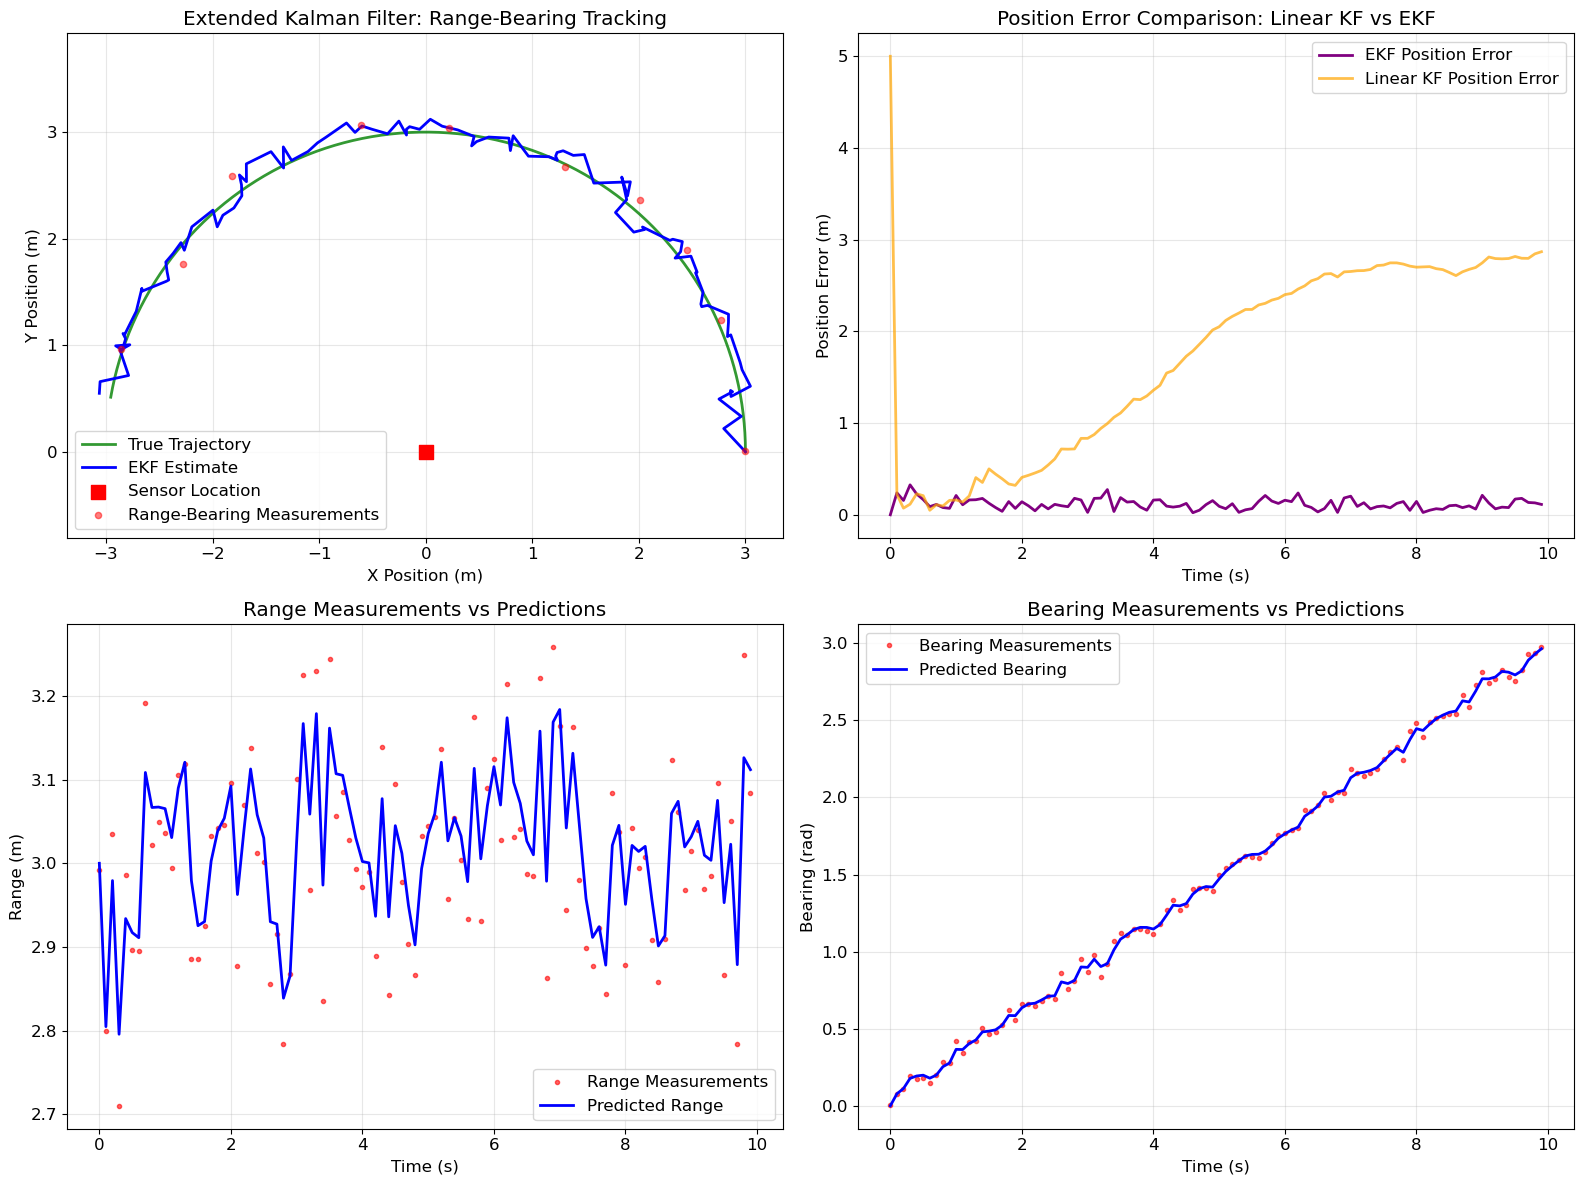


Performance Comparison:
EKF RMSE (range-bearing): 0.1305 m
Linear KF RMSE (direct position): 2.2897 m
Range measurement noise std: 0.100 m
Bearing measurement noise std: 0.050 rad


In [9]:
# Visualization of EKF Results

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: EKF trajectory comparison
ax1.plot(true_states_ekf[:, 0], true_states_ekf[:, 1], 'g-', linewidth=2, 
         label='True Trajectory', alpha=0.8)
ax1.plot(estimated_states_ekf[:, 0], estimated_states_ekf[:, 1], 'b-', linewidth=2, 
         label='EKF Estimate')
ax1.scatter(0, 0, c='red', s=100, marker='s', label='Sensor Location', zorder=10)

# Convert range-bearing measurements back to Cartesian for visualization
meas_x = measurements_rb[:, 0] * np.cos(measurements_rb[:, 1])
meas_y = measurements_rb[:, 0] * np.sin(measurements_rb[:, 1])
ax1.scatter(meas_x[::10], meas_y[::10], c='red', s=20, alpha=0.5, 
           label='Range-Bearing Measurements', zorder=5)

ax1.set_xlabel('X Position (m)')
ax1.set_ylabel('Y Position (m)')
ax1.set_title('Extended Kalman Filter: Range-Bearing Tracking')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# Plot 2: Position errors comparison (Linear KF vs EKF)
time_ekf = np.arange(0, len(position_errors_ekf)) * dt
ax2.plot(time_ekf, position_errors_ekf, 'purple', linewidth=2, label='EKF Position Error')
if len(position_errors) >= len(position_errors_ekf):
    ax2.plot(time_ekf, position_errors[:len(position_errors_ekf)], 'orange', 
             linewidth=2, alpha=0.7, label='Linear KF Position Error')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Position Error (m)')
ax2.set_title('Position Error Comparison: Linear KF vs EKF')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Range and bearing measurements vs predictions
predicted_measurements = []
for k in range(len(estimated_states_ekf)):
    pred_meas = range_bearing_observation(estimated_states_ekf[k])
    predicted_measurements.append(pred_meas)
predicted_measurements = np.array(predicted_measurements)

ax3.plot(time_ekf, measurements_rb[:, 0], 'r.', alpha=0.6, label='Range Measurements')
ax3.plot(time_ekf, predicted_measurements[:, 0], 'b-', linewidth=2, label='Predicted Range')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Range (m)')
ax3.set_title('Range Measurements vs Predictions')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Bearing measurements
ax4.plot(time_ekf, measurements_rb[:, 1], 'r.', alpha=0.6, label='Bearing Measurements')
ax4.plot(time_ekf, predicted_measurements[:, 1], 'b-', linewidth=2, label='Predicted Bearing')
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Bearing (rad)')
ax4.set_title('Bearing Measurements vs Predictions')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Performance comparison
rmse_ekf = np.sqrt(np.mean(position_errors_ekf**2))
print(f"\nPerformance Comparison:")
print(f"EKF RMSE (range-bearing): {rmse_ekf:.4f} m")
if 'rmse_position' in locals():
    print(f"Linear KF RMSE (direct position): {rmse_position:.4f} m")
print(f"Range measurement noise std: {range_noise_std:.3f} m")
print(f"Bearing measurement noise std: {bearing_noise_std:.3f} rad")

## Conclusion and Summary

### Key Takeaways

1. **Kalman Filter Fundamentals**:
   - Optimal estimator for linear Gaussian systems
   - Recursive algorithm with prediction and update phases
   - Minimizes mean square error under linearity and Gaussianity assumptions

2. **Mathematical Foundation**:
   - Based on Bayesian inference and Gaussian distributions
   - Uses linear algebra operations for efficient computation
   - Provides uncertainty quantification through covariance matrices

3. **Implementation Insights**:
   - Proper tuning of process and measurement noise matrices is crucial
   - Filter performance depends on the accuracy of the system model
   - Initialization can affect convergence, especially for poor initial guesses

4. **Extensions and Variants**:
   - Extended Kalman Filter (EKF) for nonlinear systems
   - Unscented Kalman Filter (UKF) for better nonlinear handling
   - Particle filters for highly nonlinear/non-Gaussian systems

### Applications

The Kalman filter has widespread applications in:
- **Aerospace**: Aircraft and spacecraft navigation
- **Robotics**: Mobile robot localization and mapping (SLAM)
- **Automotive**: Vehicle tracking and autonomous navigation
- **Finance**: Portfolio optimization and risk management
- **Signal Processing**: Noise reduction and signal estimation

### Limitations and Considerations

1. **Linear Gaussian Assumption**: Performance degrades for highly nonlinear systems
2. **Model Accuracy**: Requires accurate system and measurement models
3. **Computational Complexity**: Matrix operations scale with state dimension
4. **Divergence**: Can diverge if assumptions are severely violated

### Future Directions

- **Machine Learning Integration**: Learned Kalman filters and neural network variants
- **Distributed Filtering**: Multi-agent and sensor network applications
- **Robust Filtering**: Handling model uncertainties and outliers
- **Quantum Filtering**: Applications in quantum state estimation

---

**References:**
1. Kalman, R. E. (1960). "A new approach to linear filtering and prediction problems"
2. Bar-Shalom, Y., Li, X. R., & Kirubarajan, T. (2001). "Estimation with applications to tracking and navigation"
3. Thrun, S., Burgard, W., & Fox, D. (2005). "Probabilistic robotics"

---

*This notebook provides a comprehensive academic treatment of the Kalman filter with mathematical rigor and practical implementations. The examples demonstrate both theoretical understanding and practical application of this fundamental algorithm in estimation theory.*